# Проект Титаник

## Описание проекта:  

Гибель «Титаника» — одно из самых печально известных кораблекрушений в истории.  
15 апреля 1912 года, во время своего первого рейса, широко считавшийся «непотопляемым» лайнер «Титаник» затонул после столкновения с айсбергом. К сожалению, спасательных шлюпок не хватило на всех находившихся на борту, в результате чего погибли 1502 из 2224 пассажиров и членов экипажа.  
Хотя в выживании и присутствовал элемент удачи, похоже, что у некоторых групп людей шансы на выживание были выше, чем у других.

## Цель проекта: 
Создать прогностическую модель, которая отвечает на вопрос: «Какие категории людей имели больше шансов выжить?», используя данные о пассажирах.

## Описание данных:  
Два датасета: train.csv, test.csv

**Survived** Целевая переменная 0 — пассажир погиб, 1 — выжил  
**PassengerId** Уникальный идентификатор пассажира  
**Pclass** Класс билета: 1 (первый), 2 (второй), 3 (третий)  
**Name** Имя пассажира  
**Sex** Пол male / female  
**Age** Возраст в годах  
**SibSp** Количество братьев, сестер, супругов на борту  
**Parch** Количество родителей/детей на борту  
**Ticket** Номер билета  
**Fare** Стоимость билета  
**Cabin** Номер каюты  
**Embarked** Порт посадки: C (Cherbourg), Q (Queenstown), S (Southampton)  

Дополнительные пояснения:  
**SibSp**: братья/сёстры + муж/жена  
**Parch**: родители + дети (не учитывает родственников из SibSp)  

## План проекта:
1. Загрузка и просмотр данных
2. Исследовательский анализ данных
3. Подготовка данных к моделированию
4. Создание модели МО
5. Итоговый вывод и подготовка submit

### 1. Загрузка и просмотр данных

In [1]:
#  для начала загрузим библиотеки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import warnings

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# загружаем тренировочный и тестовый датасет

data_train = pd.read_csv('data/train.csv')
data_test = pd.read_csv('data/test.csv')

In [4]:
# выводим первые строки и размерности train

display(data_train.head())
print(f'Размер train: {data_train.shape}')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Размер train: (891, 12)


In [5]:
# выводим первые строки и размерности test

display(data_test.head())
print(f'Размер test: {data_test.shape}')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Размер test: (418, 11)


#### Вывод по 1 разделу:  
Имеем 2 датафрейма, трейн и тест. Трейн - 891 строка и 12 столбцов, трейн - 418 строк и 11 столбцов.

### 2. Исследовательский анализ данных

Посмотрим типы данных, по необходимости преобразуем. Так же пропуски, дубликаты. После этого сделаем статистический анализ и визуализацию.

#### 2.1 Первичный анализ

In [6]:
# типы данных

print(f'\033[1mТип данных train:\033[0m\n{data_train.dtypes}')
print('--'* 12)
print(f'\033[1mТип данных test:\033[0m\n{data_test.dtypes}')

Тип данных train:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
------------------------
Тип данных test:
PassengerId      int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


На этапе подготовки данных, закодируем значения по столбцам Sex и Embarked.

In [7]:
# пропуски

print(f'\033[1mПропуски train:\033[0m\n{data_train.isna().sum().sort_values(ascending = False)}')
print(f'\033[1mПропуски test:\033[0m\n{data_test.isna().sum().sort_values(ascending = False)}')

Пропуски train:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64
Пропуски test:
Cabin          327
Age             86
Fare             1
PassengerId      0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Embarked         0
dtype: int64


Cabin 687(train) и 327(test) пропусков, Age 177(train) и 86(test), Embarked 2(train), Fare 1(test). Cabin - сделаем отдельный столбец с бинарным признаком, есть каюта или нет. Age - заполним медианой по группам. Embarked - модой. Fare - медиана по группам.

In [8]:
# заполнение пропусков и удаление старого столбца

data_train['has_cabin'] = data_train['Cabin'].notna().astype(int)
data_test['has_cabin'] = data_test['Cabin'].notna().astype(int)

data_train = data_train.drop(columns = 'Cabin')
data_test = data_test.drop(columns = 'Cabin')

age_medians = data_train.groupby(['Sex', 'Pclass'])['Age'].median()

def fill_age(row):
    if pd.isna(row['Age']):
        return age_medians[(row['Sex'], row['Pclass'])]
    return row['Age']

data_train['Age'] = data_train.apply(fill_age, axis = 1)
data_test['Age'] = data_test.apply(fill_age, axis = 1)

mode_embarked = data_train['Embarked'].mode()[0]
data_train['Embarked'] = data_train['Embarked'].fillna(mode_embarked)

fare_medians = data_train.groupby('Pclass')['Fare'].median()

def fill_fare(row):
    if pd.isna(row['Fare']):
        return fare_medians[row['Pclass']]
    return row['Fare']

data_test['Fare'] = data_test.apply(fill_fare, axis=1)

In [9]:
# проверка

print(data_train.isnull().sum())
print(data_test.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
has_cabin      0
dtype: int64
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
has_cabin      0
dtype: int64


In [10]:
# дубликаты

print(f'Дубликаты train: {data_train.duplicated().sum()}')
print(f'Дубликаты test: {data_test.duplicated().sum()}')

Дубликаты train: 0
Дубликаты test: 0


#### 2.2 Cтатистический анализ

In [11]:
# статистика

print('Train')
display(data_train.describe())
display(data_train.describe(exclude = 'number'))

Train


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,has_cabin
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208,0.228956
std,257.353842,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429,0.420397
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Braund, Mr. Owen Harris",male,347082,S
freq,1,577,7,646


In [12]:
data_train[data_train['Fare'] > 100]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,S,1
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,35.00,1,0,PC 17569,146.5208,C,1
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,S,1
118,119,0,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,C,1
195,196,1,1,"Lurette, Miss. Elise",female,58.00,0,0,PC 17569,146.5208,C,1
215,216,1,1,"Newell, Miss. Madeleine",female,31.00,1,0,35273,113.2750,C,1
258,259,1,1,"Ward, Miss. Anna",female,35.00,0,0,PC 17755,512.3292,C,0
268,269,1,1,"Graham, Mrs. William Thompson (Edith Junkins)",female,58.00,0,1,PC 17582,153.4625,S,1
269,270,1,1,"Bissette, Miss. Amelia",female,35.00,0,0,PC 17760,135.6333,S,1
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,S,1


Значение - в норме, аномалий нет. Объединим колонки SibSp и Parch в одну колонку FamilySize. А так же добавим признак, был ли пассажир один. А так же сделаем категоризацию возраста.

In [13]:
# FamilySize

data_train['FamilySize'] = data_train['SibSp'] + data_train['Parch'] + 1
data_test['FamilySize'] = data_test['SibSp'] + data_test['Parch'] + 1
data_train['IsAlone'] = (data_train['FamilySize'] == 1).astype(int)
data_test['IsAlone'] = (data_test['FamilySize'] == 1).astype(int)

In [14]:
# age cat

def age_category(age):
    if age <= 10:
        return 'child'
    elif age <= 20:
        return 'teen'
    elif age <= 30:
        return 'young'
    elif age <= 40:
        return 'adult'
    elif age <= 50:
        return 'middle'
    elif age <= 60:
        return 'pre_retirement'
    else:
        return 'retirement'

data_train['AgeGroup'] = data_train['Age'].apply(age_category)
data_test['AgeGroup'] = data_test['Age'].apply(age_category)

In [15]:
# проверка

display(data_train.head())
display(data_test.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2,0,young
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,0,adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,1,young
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,0,adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,1,adult


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin,FamilySize,IsAlone,AgeGroup
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,0,1,1,adult
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0,2,0,middle
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,0,1,1,retirement
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,0,1,1,young
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0,3,0,young


#### 2.3 Визуализация

In [16]:
# базовые настройки seaborn

sns.set_theme()
sns.set_style('whitegrid')
sns.set_context('notebook')

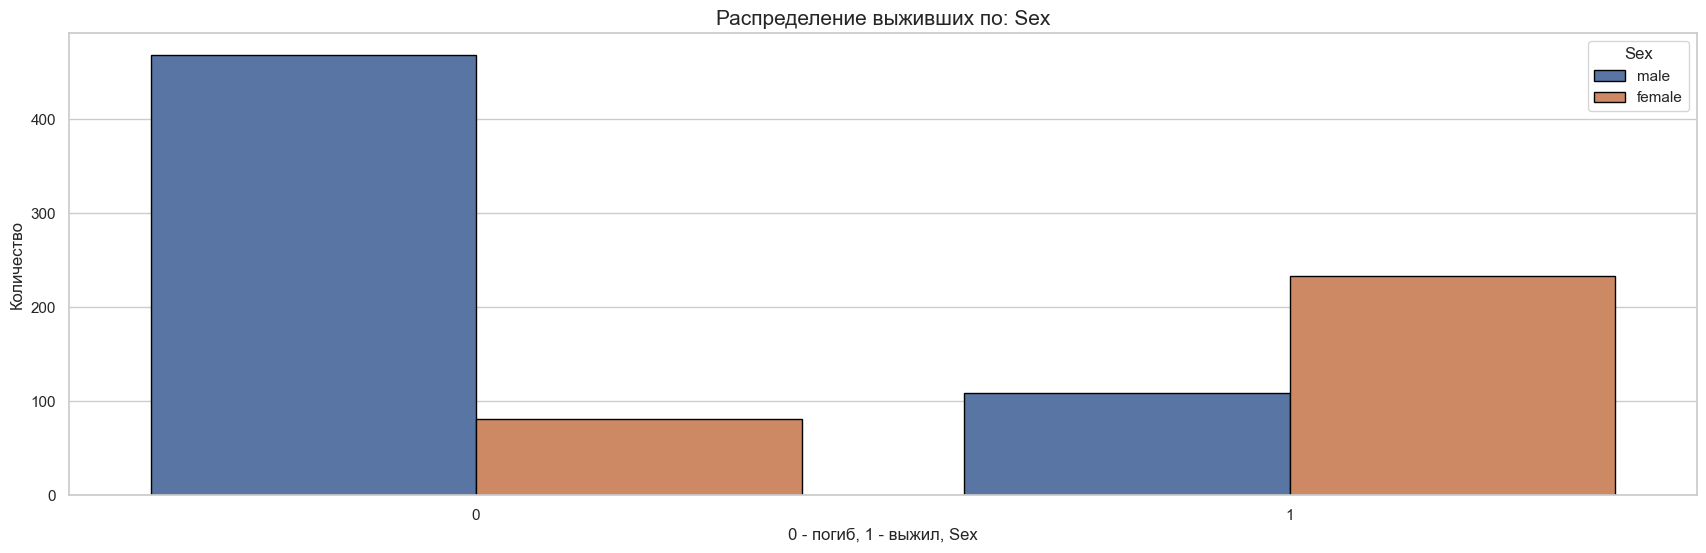

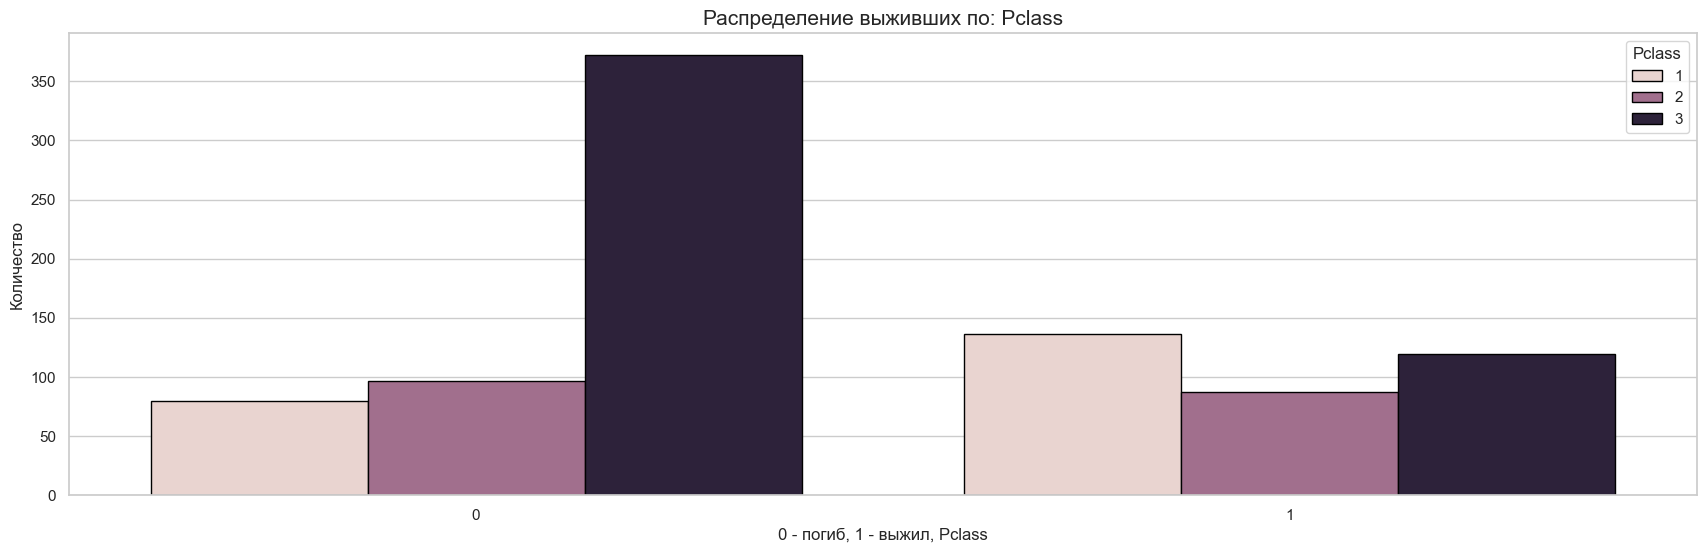

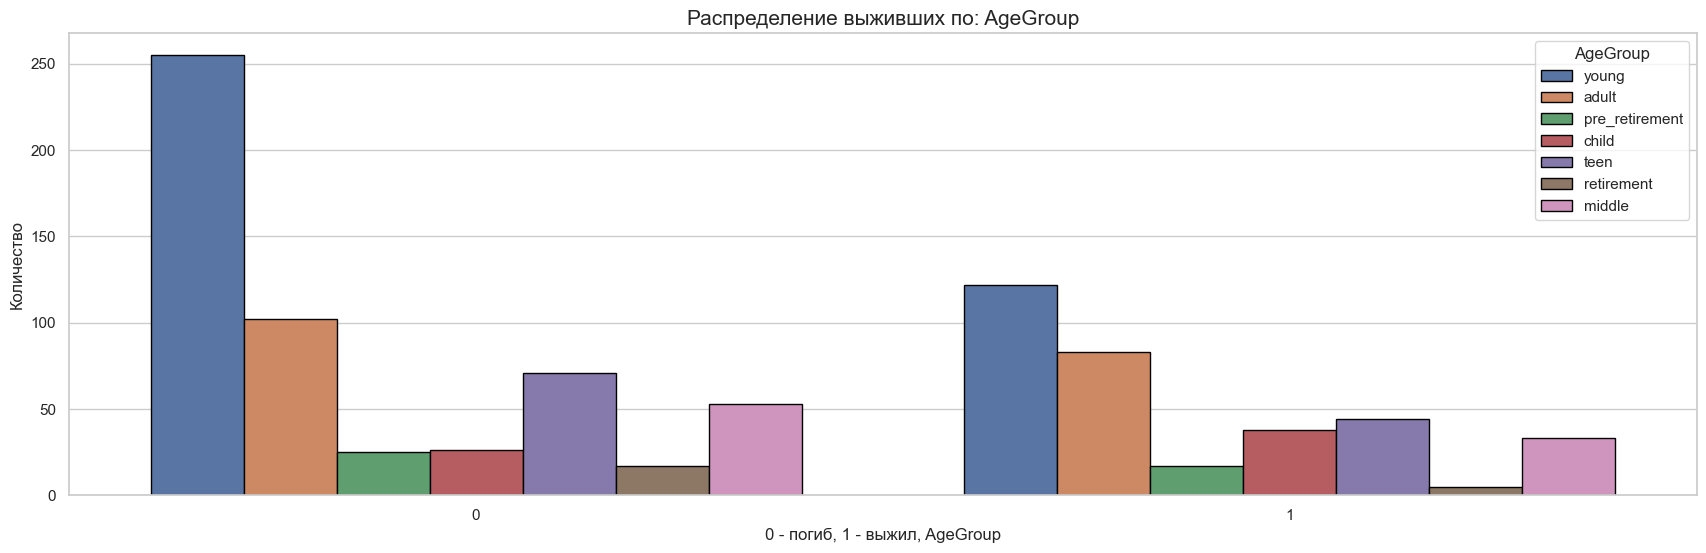

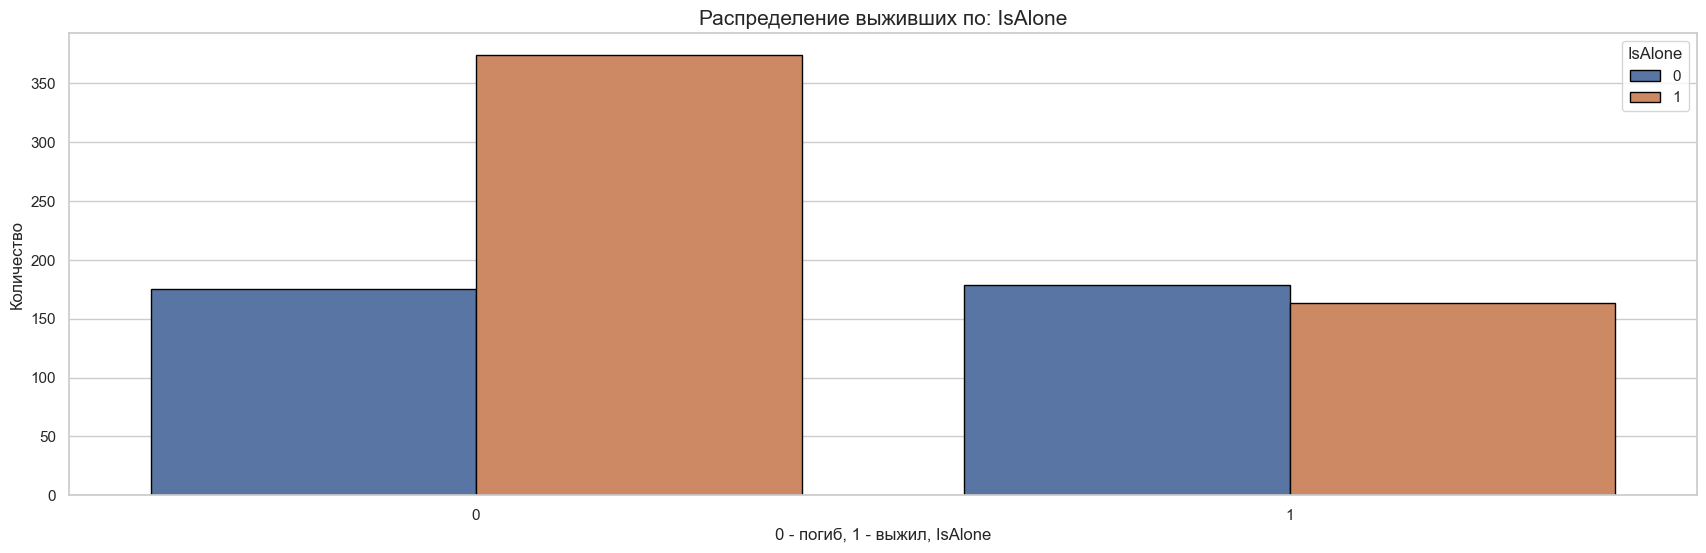

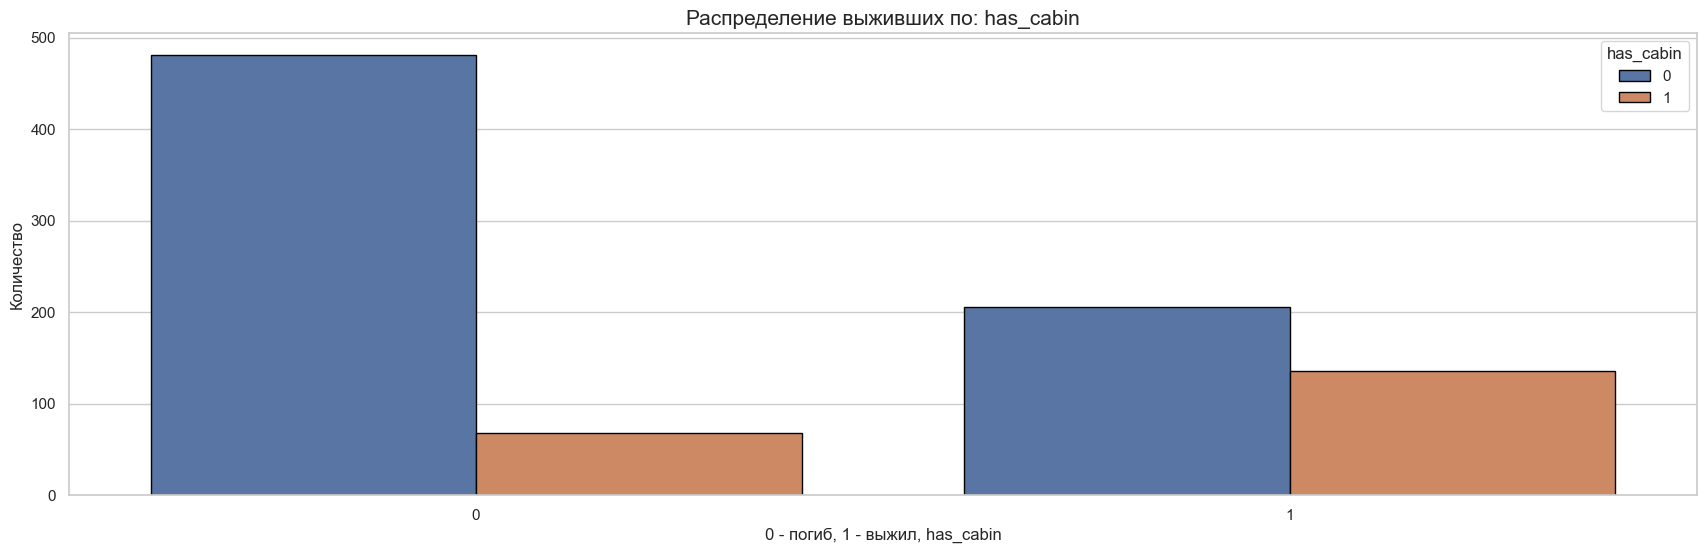

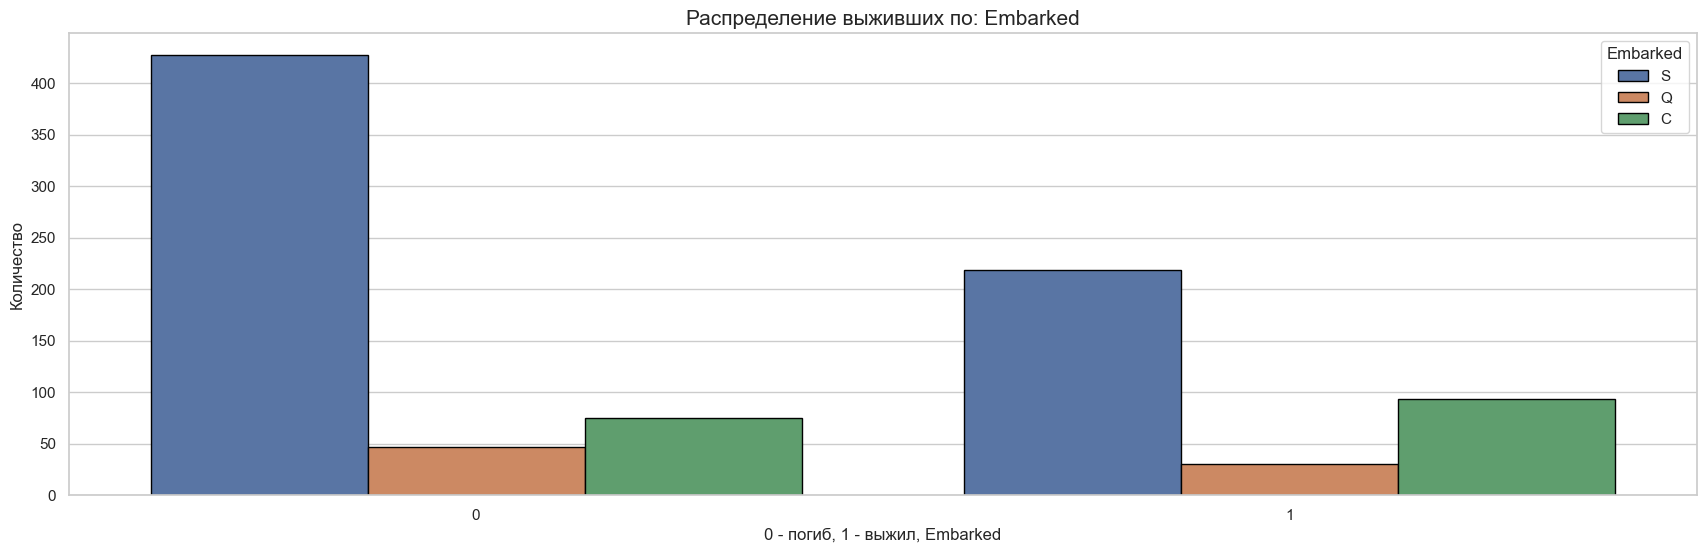

In [17]:
# строим графики для категориальных значений

cat_cols = ['Sex', 'Pclass', 'AgeGroup', 'IsAlone', 'has_cabin', 'Embarked']

for i in cat_cols:

    plt.figure(figsize = (21, 6))
    sns.countplot(
        data = data_train, 
        x = 'Survived',
        hue = i,
        stat = 'count',
        edgecolor = 'black'
    )
    plt.title(f'Распределение выживших по: {i}', fontsize = 15)
    plt.xlabel(f'0 - погиб, 1 - выжил, {i}')
    plt.ylabel('Количество')

Можем сделать вывод:
- Женщин выжило больше
- Все классы выжили примерно одинаково, но 3 класс - больше погибших
- По возрасту, меньше всего выжило более старших людей
- По распределению с семьей или без, выжило примерно одинаково, а погибших больше, тех кто был один.
- С каютами выживших примерно поровну, но значительно больше погибло, тех у кого не было номера каюты.
- Большинство людей было из порта отправления Southampton

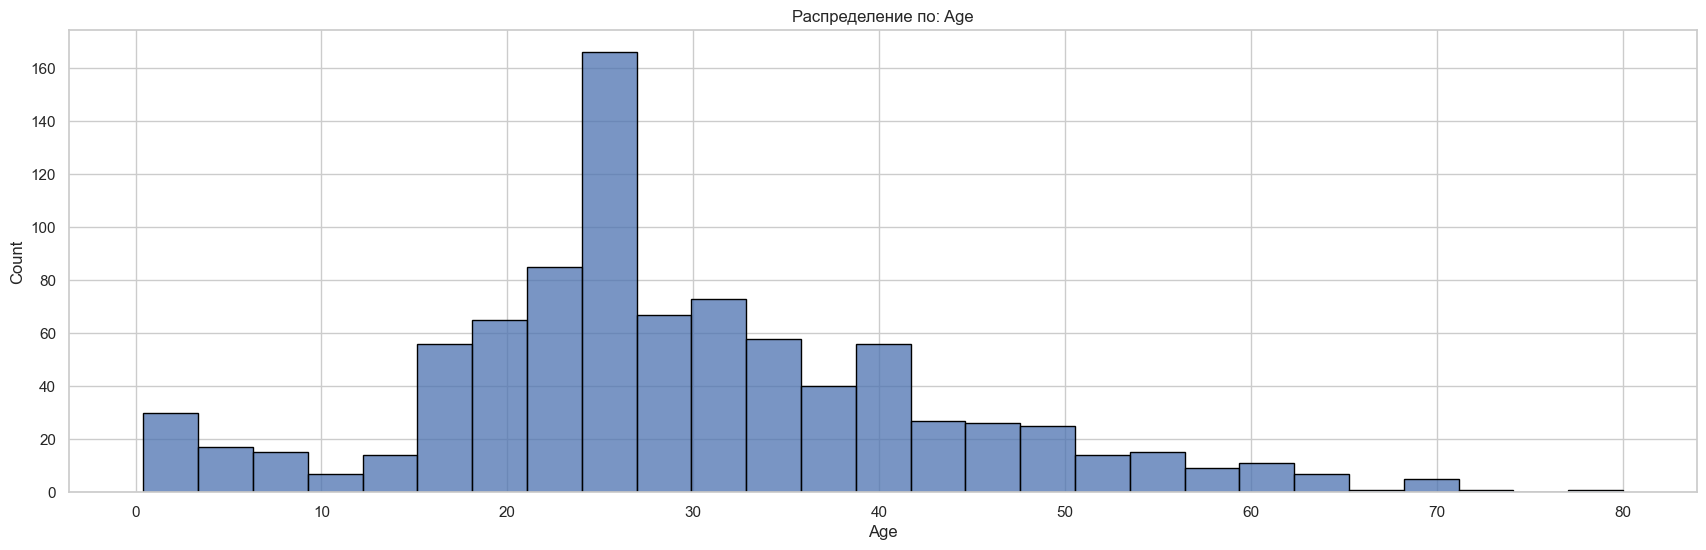

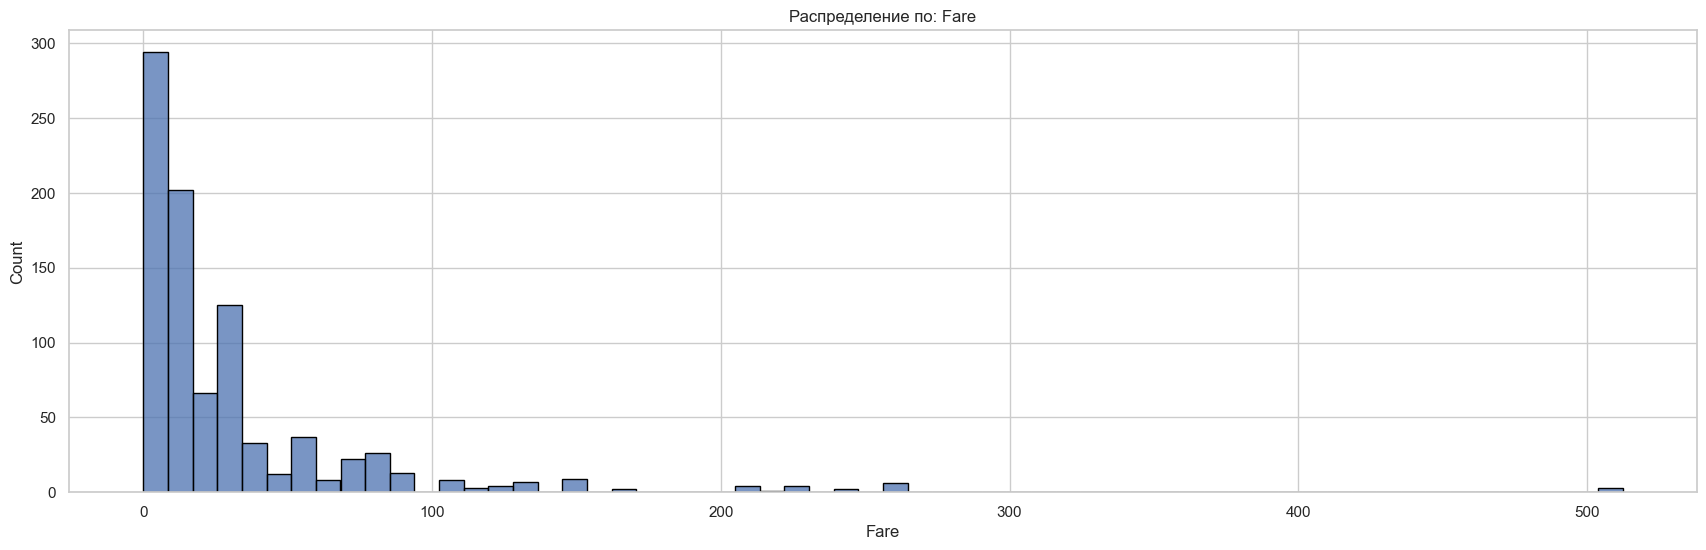

In [18]:
# строим графики для числовых значений

num_cols = ['Age', 'Fare']

for i in num_cols:
    plt.figure(figsize = (21, 6))
    sns.histplot(
        data = data_train,
        x = i,
        bins = 'auto',
        edgecolor = 'black')
    plt.title(f'Распределение по: {i}')

Видим нормальное распределение по возрасту, в основном молодеж. Цена билета ассиметрична - со смешением от дешевых билетов к дорогим, по убыванию.

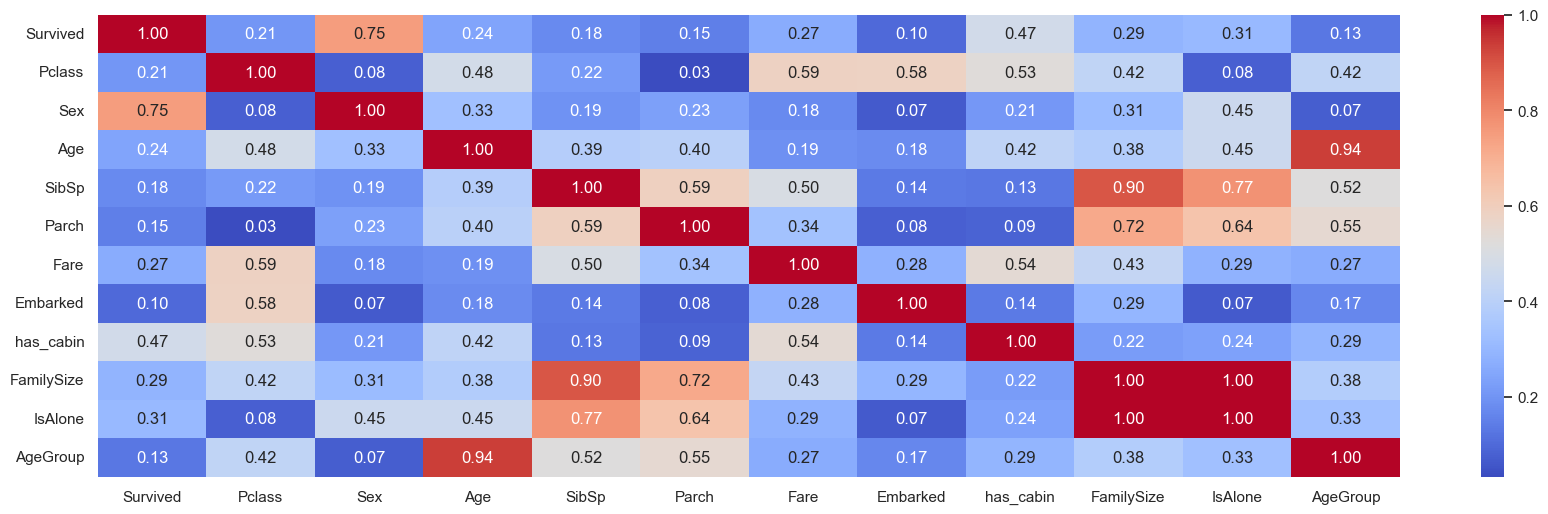

In [19]:
# корреляционный анализ

columns = ['PassengerId', 'Name', 'Ticket']
data_clean = data_train.drop(columns = columns)
interval_cols = ['Age', 'Fare']

phik_matrix = data_clean.phik_matrix(interval_cols = interval_cols)

plt.figure(figsize = (21, 6))
sns.heatmap(
    phik_matrix,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm'
);


Наибольшая корреляция у выживаемости:
- Пол
- Наличие данных о каюте
- Небольшая по один ли был пассажир

Так же видим мультиколлинеарность между признаками Age - AgeGroup, SibSp - FamilySize - Parch, IsAlone - Family size. Удалим коррелирующие признаки.

In [20]:
# удаление мультиколлинеарности

columns = ['SibSp', 'Parch', 'IsAlone', 'AgeGroup']

data_train = data_train.drop(columns = columns)

In [21]:
# проверка

print(data_train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Ticket',
       'Fare', 'Embarked', 'has_cabin', 'FamilySize'],
      dtype='str')


Выживаемость сильно зависит от пола (женщины — 74%, мужчины — 19%), класса (1-й — 63%, 3-й — 24%) и наличия каюты (67% vs 30%). Семейные пассажиры выживали чаще одиночек. Возраст влияет нелинейно: дети выживают чаще, пожилые — реже. Пропуски в Age заполнены медианой по полу и классу, Cabin преобразован в has_cabin, созданы признаки FamilySize, IsAlone, AgeGroup.

### 3. Подготовка данных к моделированию

In [22]:
display(data_train.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,has_cabin,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,0,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,1,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,1,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,0,1


In [23]:
display(data_test.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin,FamilySize,IsAlone,AgeGroup
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,0,1,1,adult
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0,2,0,middle
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,0,1,1,retirement
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,0,1,1,young
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0,3,0,young


In [24]:
# извлечение титула из имени

def extract_title(name):
    """Извлекает титул из имени пассажира"""
    if 'Mr.' in name:
        return 'Mr'
    elif 'Mrs.' in name:
        return 'Mrs'
    elif 'Miss.' in name:
        return 'Miss'
    elif 'Master.' in name:
        return 'Master'
    else:
        return 'Rare'

data_train['Title'] = data_train['Name'].apply(extract_title)
data_test['Title'] = data_test['Name'].apply(extract_title)


In [25]:
# преобразуем тестовый датафрейм

columns = ['SibSp', 'Parch', 'IsAlone', 'AgeGroup']

data_test = data_test.drop(columns = columns)

In [26]:
# проверка

print(data_train.columns)
print(data_test.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Ticket',
       'Fare', 'Embarked', 'has_cabin', 'FamilySize', 'Title'],
      dtype='str')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'Ticket', 'Fare',
       'Embarked', 'has_cabin', 'FamilySize', 'Title'],
      dtype='str')


In [27]:
# проверка на дисбаланс классов

print(data_train['Survived'].value_counts())
print(data_train['Survived'].value_counts(normalize=True))

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Есть небольшой дисбаланс, сохраним пропорции в разбиении на трейн и тест.

In [28]:
# разделяем данные на тренировочные и тестовые

X = data_train.drop(columns = ['PassengerId', 'Survived', 'Name', 'Ticket'])
y = data_train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [29]:
# размерность после разделения

print(f'Train: X {X_train.shape}')
print(f'Train: y {y_train.shape}')
print(f'Test: X {X_test.shape}')
print(f'Test: y {y_test.shape}')

Train: X (712, 8)
Train: y (712,)
Test: X (179, 8)
Test: y (179,)


In [30]:
# масштабирование числовых признаков

scaler = StandardScaler()

X_train[['Age', 'Fare']] = scaler.fit_transform(X_train[['Age', 'Fare']])
X_test[['Age', 'Fare']] = scaler.transform(X_test[['Age', 'Fare']])

In [31]:
# кодирование категорий

le_sex = LabelEncoder()

X_train['Sex'] = le_sex.fit_transform(X_train['Sex'])
X_test['Sex'] = le_sex.transform(X_test['Sex'])

le_emb = LabelEncoder()

X_train['Embarked'] = le_emb.fit_transform(X_train['Embarked'].astype(str))
X_test['Embarked'] = le_emb.transform(X_test['Embarked'].astype(str))

print("Sex classes:", le_sex.classes_)
print("Embarked classes:", le_emb.classes_)

Sex classes: ['female' 'male']
Embarked classes: ['C' 'Q' 'S']


In [32]:
# кодирование категорий

ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

ohe.fit(X_train[['Title']])

ohe_feature_names = ohe.get_feature_names_out(['Title'])

X_train_encoded = ohe.transform(X_train[['Title']])

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=ohe_feature_names,
    index=X_train.index
)

X_train = pd.concat([X_train, X_train_encoded_df], axis=1)
X_train = X_train.drop('Title', axis=1)

X_test_encoded = ohe.transform(X_test[['Title']])
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=ohe_feature_names,
    index=X_test.index
)

X_test = pd.concat([X_test, X_test_encoded_df], axis=1)

X_test = X_test.drop('Title', axis=1)

In [33]:
# проверка

display(X_train.head())
display(X_test.head())

,Pclass,Sex,Age,Fare,Embarked,has_cabin,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
692,3,1,-0.322182,0.513812,2,0,1,0.0,1.0,0.0,0.0
481,2,1,0.053575,-0.662563,2,0,1,0.0,1.0,0.0,0.0
527,1,1,0.805089,3.955399,2,1,1,0.0,1.0,0.0,0.0
855,3,0,-0.848242,-0.467874,2,0,2,0.0,0.0,1.0,0.0
801,2,0,0.128726,-0.115977,2,0,3,0.0,0.0,1.0,0.0


,Pclass,Sex,Age,Fare,Embarked,has_cabin,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
565,3,1,-0.397333,-0.159704,2,0,3,0.0,1.0,0.0,0.0
160,3,1,1.105694,-0.327324,2,0,2,0.0,1.0,0.0,0.0
553,3,1,-0.547636,-0.512122,0,0,1,0.0,1.0,0.0,0.0
860,3,1,0.880240,-0.368795,2,0,3,0.0,1.0,0.0,0.0
241,3,0,-0.585212,-0.339817,1,0,2,1.0,0.0,0.0,0.0


Сделали масштабирование числовых признаков 'Age', 'Fare' - с помощью Standard Scaler. Кодирование 'Sex', 'Embarked' - Label Encoder.  Далее приступаем к созданию моделей МО.

### 4. Создание моделей МО

Сделаем 3 модели. Logistic Regression - как baseline, Catboost и RandomForest.

In [34]:
# логистическая регрессия - baseline

lr_bs = LogisticRegression()

lr_bs.fit(X_train, y_train)

y_pred_lr_bs = lr_bs.predict(X_test)
y_proba_lr_bs = lr_bs.predict_proba(X_test)

In [35]:
# оценка логистической регрессии(baseline)

lr_bs_accuracy = accuracy_score(y_test, y_pred_lr_bs)
lr_bs_precision = precision_score(y_test, y_pred_lr_bs)
lr_bs_recall = recall_score(y_test, y_pred_lr_bs)
lr_bs_roc_auc = roc_auc_score(y_test, y_proba_lr_bs[:, 1])

print(f'Accuracy lr_bs: {lr_bs_accuracy:.2f}')
print(f'Precision lr_bs: {lr_bs_precision:.2f}')
print(f'Recall lr_bs: {lr_bs_recall:.2f}')
print(f'Roc_auc lr_bs: {lr_bs_roc_auc:.2f}')

Accuracy lr_bs: 0.82
Precision lr_bs: 0.78
Recall lr_bs: 0.72
Roc_auc lr_bs: 0.87


Для baseline - неплохие результаты. Дальше попробуем подобрать гиперпараметры.

In [36]:
# логистическая регрессия с подбором гиперпараметров

param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.1, 0.5, 1, 10, 50],
    'solver': ['lbfgs', 'liblinear', 'saga', 'newton-cg'],
    'max_iter': [1000],
    'class_weight': ['None', 'balanced']
}

grid_lr = GridSearchCV(
    estimator = lr_bs,
    param_grid = param_grid_lr,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1,
    verbose = 1
)

grid_lr.fit(X_train, y_train);

Fitting 5 folds for each of 120 candidates, totalling 600 fits


In [37]:
# результаты подбора гиперпараметров для логистической регрессии

print(f'Лучшие параметры: {grid_lr.best_params_}')

best_model_lr = grid_lr.best_estimator_

y_pred_lr = best_model_lr.predict(X_test)
y_proba_lr = best_model_lr.predict_proba(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_proba_lr[:, 1])

print(f'Accuracy lr: {lr_accuracy:.2f}')
print(f'Precision lr: {lr_precision:.2f}')
print(f'Recall lr: {lr_recall:.2f}')
print(f'Roc_auc lr: {lr_roc_auc:.2f}')

Лучшие параметры: {'C': 50, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy lr: 0.84
Precision lr: 0.77
Recall lr: 0.83
Roc_auc lr: 0.88


In [38]:
# сравнение базовой модели логистической регресии с подобранными гиперпараметрами

results = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'Logistic Regression (tuned)'],
    'Accuracy': [lr_bs_accuracy, lr_accuracy],
    'Precision': [lr_bs_precision, lr_precision],
    'Recall': [lr_bs_recall, lr_recall],
    'ROC-AUC': [lr_bs_roc_auc, lr_roc_auc]
})

results = results.round(4).sort_values('ROC-AUC', ascending=False)

print(results.to_string(index=False))

                         Model  Accuracy  Precision  Recall  ROC-AUC
   Logistic Regression (tuned)    0.8380     0.7703  0.8261   0.8764
Logistic Regression (baseline)    0.8156     0.7812  0.7246   0.8719


In [39]:
X_train

,Pclass,Sex,Age,Fare,Embarked,has_cabin,FamilySize,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
692,3,1,-0.322182,0.513812,2,0,1,0.0,1.0,0.0,0.0
481,2,1,0.053575,-0.662563,2,0,1,0.0,1.0,0.0,0.0
527,1,1,0.805089,3.955399,2,1,1,0.0,1.0,0.0,0.0
855,3,0,-0.848242,-0.467874,2,0,2,0.0,0.0,1.0,0.0
801,2,0,0.128726,-0.115977,2,0,3,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
359,3,0,-0.585212,-0.498500,1,0,1,1.0,0.0,0.0,0.0
258,1,0,0.429332,10.005329,0,0,1,1.0,0.0,0.0,0.0
736,3,0,1.406300,0.053205,2,0,5,0.0,0.0,1.0,0.0
462,1,1,1.331148,0.139097,2,1,1,0.0,1.0,0.0,0.0


In [40]:
# catboost

cat_cols = ['Pclass', 'Sex', 'Embarked', 'has_cabin', 'FamilySize', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
X_train[cat_cols] = X_train[cat_cols].astype(int)

param_grid_cb = {
    'iterations': [500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5, 7]
}

cb = CatBoostClassifier(verbose=False, allow_writing_files=False)

grid_cb = GridSearchCV(
    estimator = cb,
    param_grid = param_grid_cb,
    cv = 5,
    scoring = 'roc_auc',
    n_jobs = -1,
    verbose = 0
)

grid_cb.fit(X_train, y_train, cat_features=cat_cols);

In [41]:
best_model_cb = grid_cb.best_estimator_

X_test[cat_cols] = X_test[cat_cols].astype(int)

y_pred_cb = best_model_cb.predict(X_test)
y_proba_cb = best_model_cb.predict_proba(X_test)

cb_accuracy = accuracy_score(y_test, y_pred_lr)
cb_precision = precision_score(y_test, y_pred_lr)
cb_recall = recall_score(y_test, y_pred_lr)
cb_roc_auc = roc_auc_score(y_test, y_proba_lr[:, 1])

print(f'Accuracy cb: {cb_accuracy:.2f}')
print(f'Precision cb: {cb_precision:.2f}')
print(f'Recall cb: {cb_recall:.2f}')
print(f'Roc_auc cb: {cb_roc_auc:.2f}')

Accuracy cb: 0.84
Precision cb: 0.77
Recall cb: 0.83
Roc_auc cb: 0.88


### 5. Итоговые выводы и подготовка submit

Подготовим submit

In [42]:
submit = pd.read_csv('data/test.csv')

In [43]:
passenger_ids = submit['PassengerId'].copy()

In [44]:
submit['has_cabin'] = submit['Cabin'].notna().astype(int)
submit['FamilySize'] = submit['SibSp'] + submit['Parch'] + 1

def extract_title(name):
    if 'Mr.' in name:
        return 'Mr'
    elif 'Mrs.' in name:
        return 'Mrs'
    elif 'Miss.' in name:
        return 'Miss'
    elif 'Master.' in name:
        return 'Master'
    else:
        return 'Rare'

submit['Title'] = submit['Name'].apply(extract_title)
submit = submit.drop(columns=['PassengerId', 'Name', 'Ticket', 'SibSp', 'Parch', 'Cabin'], errors='ignore')

age_medians = data_train.groupby(['Sex', 'Pclass'])['Age'].median()

def fill_age(row):
    if pd.isna(row['Age']):
        return age_medians[(row['Sex'], row['Pclass'])]
    return row['Age']

submit['Age'] = submit.apply(fill_age, axis=1)

fare_medians = data_train.groupby('Pclass')['Fare'].median()
submit['Fare'] = submit.apply(
    lambda row: fare_medians[row['Pclass']] if pd.isna(row['Fare']) else row['Fare'], 
    axis=1
)

mode_embarked = data_train['Embarked'].mode()[0]
submit['Embarked'] = submit['Embarked'].fillna(mode_embarked)

submit_encoded = ohe.transform(submit[['Title']])
ohe_feature_names = ohe.get_feature_names_out(['Title'])
submit_encoded_df = pd.DataFrame(
    submit_encoded,
    columns=ohe_feature_names,
    index=submit.index
)
submit = pd.concat([submit, submit_encoded_df], axis=1)
submit = submit.drop('Title', axis=1)

submit[['Age', 'Fare']] = scaler.transform(submit[['Age', 'Fare']])
submit['Sex'] = le_sex.transform(submit['Sex'])
submit['Embarked'] = le_emb.transform(submit['Embarked'].astype(str))

In [45]:
print("Колонки X_train:", X_train.columns.tolist())
print("Колонки submit:", submit.columns.tolist())

Колонки X_train: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'has_cabin', 'FamilySize', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
Колонки submit: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'has_cabin', 'FamilySize', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [46]:
y_pred_submit = lr_bs.predict(submit)

In [47]:
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': y_pred_submit
})

submission.to_csv('submission.csv', index=False)
print("✅ Файл submission.csv создан")
print(submission.head())
print(f"Размер: {submission.shape}")

✅ Файл submission.csv создан
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
Размер: (418, 2)


In [48]:
# распределение предсказаний
print(submission['Survived'].value_counts())
print(f"Процент выживших: {submission['Survived'].mean()*100:.1f}%")

Survived
0    248
1    170
Name: count, dtype: int64
Процент выживших: 40.7%
